# Logistic Regression Case Study: Banking Term Deposit Prediction

### Problem Statement
The classification goal is to predict whether the client will subscribe (**1**) or not (**0**) to a term deposit (variable `y`).

### Model Formula
$P(Y=1|X_i) = \frac{e^z}{1+e^z}$, where $z = \beta_0 + \sum \beta_i X_i$

---

### Feature Descriptions
1. **age**: (numeric)
2. **job**: type of job (categorical)
3. **marital**: marital status (categorical)
4. **education**: (categorical)
5. **default**: has credit in default? (categorical)
6. **housing**: has housing loan? (categorical)
7. **loan**: has personal loan? (categorical)
8. **contact**: contact communication type (categorical)
9. **month**: last contact month of year (categorical)
10. **day_of_week**: last contact day of the week (categorical)
11. **duration**: last contact duration, in seconds (numeric)
12. **campaign**: number of contacts performed during this campaign (numeric)
13. **pdays**: number of days since last contact (numeric; 999 means not contacted)
14. **previous**: number of contacts performed before this campaign (numeric)
15. **poutcome**: outcome of the previous marketing campaign (categorical)

# 1. Environment Setup
Importing libraries for data manipulation, visualization, and machine learning.

In [ ]:
import os #working directory
import pandas as pd #data processing
import numpy as np #data processing
from sklearn import preprocessing #scaling
import matplotlib.pyplot as plt #visualization
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression #Logistic Regression
from sklearn.model_selection import train_test_split #Train Test Split
import seaborn as sns #visualization
sns.set(style="whitegrid", color_codes=True) #visualization

In [ ]:
#pip install -U statsmodels

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd /content/drive/My Drive/

/content/drive/My Drive


In [ ]:
data = pd.read_csv('Banking.csv',header = 0)
print("The shape of data is --->",data.shape)
data.head()

The shape of data is ---> (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


# 2. Exploratory Data Analysis (EDA)
Visualizing the distribution of the target variable and categorical features.

/tmp/ipykernel_1205/2809354448.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y',data=data, palette='hls')


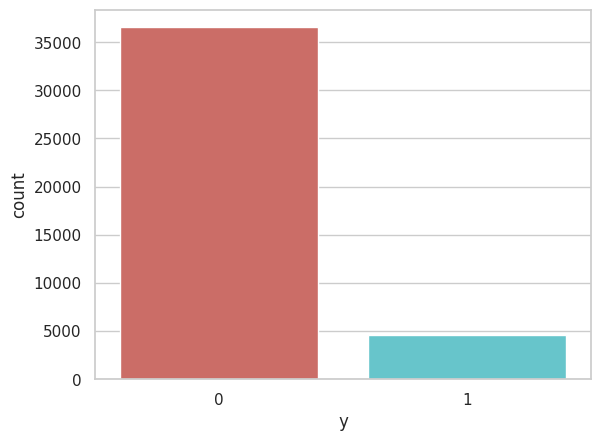

y
0    36548
1     4640
Name: count, dtype: int64


In [ ]:
sns.countplot(x='y',data=data, palette='hls')
plt.show()
print(data.y.value_counts())

In [ ]:
data.isnull().sum() #missing values

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
stats_df = pd.DataFrame(data.describe(include='all'))
stats_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,NaN
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000


<Axes: xlabel='count', ylabel='job'>

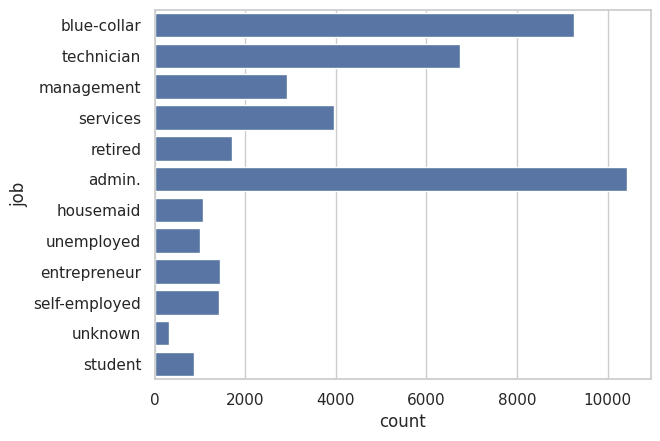

In [ ]:
sns.countplot(y="job",data = data)

<Axes: xlabel='count', ylabel='education'>

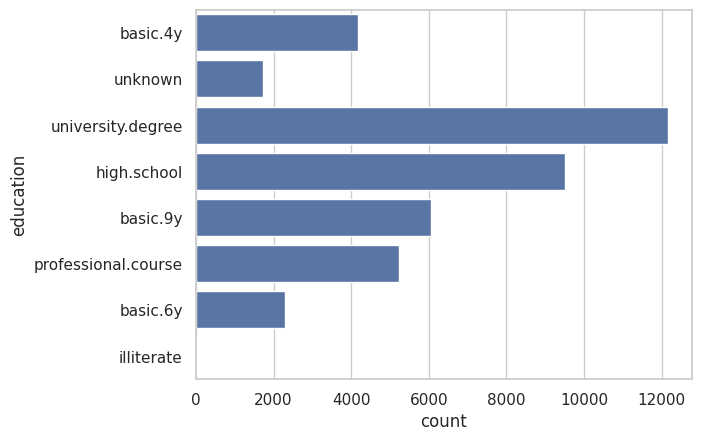

In [ ]:
sns.countplot(y="education",data = data)

<Axes: xlabel='count', ylabel='month'>

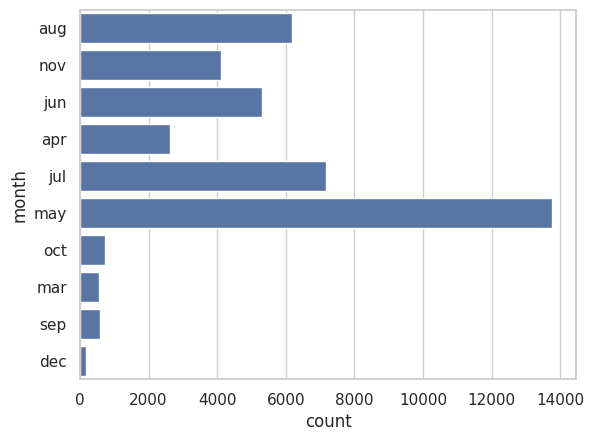

In [ ]:
sns.countplot(y="month",data = data)

# 3. Feature Engineering
Dropping unnecessary columns and converting categorical variables into dummy/indicator variables.

In [ ]:
data.columns

In [ ]:
data=data.drop(['cons_conf_idx', 'euribor3m', 'nr_employed','poutcome','pdays','day_of_week'],axis = 1)
data = data.drop(['emp_var_rate', 'cons_price_idx', 'previous'],axis = 1)
data.head()

,age,job,marital,education,default,housing,loan,contact,month,duration,campaign,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,210,1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,138,1,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,339,3,1
3,39,services,married,high.school,no,no,no,cellular,apr,185,2,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,137,1,1


In [ ]:
data_new=pd.get_dummies(data, columns =['job','marital','education','default','housing','loan','contact','month'])
data_new.head()

,age,duration,campaign,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
0,44,210,1,0,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,53,138,1,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,339,3,1,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,39,185,2,0,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,55,137,1,1,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
data_new_copy = data_new.copy()
data_new_copy.head(2)
#Improving the feature distribution through combining low dimensional variables into one variable:
data_new_copy['month_apr_mar'] = data_new_copy['month_apr'] |data_new_copy['month_mar']
data_new_copy.columns

Index(['age', 'duration', 'campaign', 'y', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'marital_unknown', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_no',
       'default_unknown', 'default_yes', 'housing_no', 'housing_unknown',
       'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'month_nov', 'month_oct', 'month_sep', 'month_apr_mar'],
      dtype='object')

In [ ]:
data_new_copy = data_new_copy.drop(['month_apr','month_mar'],axis = 1)

In [ ]:
#Creating the dummi

In [ ]:
data_new.columns

## 4. Data Partitioning
Splitting the dataset into Training (80%) and Testing (20%) sets to evaluate model generalization.

In [ ]:
y = data_new.loc[:,data_new.columns == "y"] # dependent
X = data_new.loc[:,data_new.columns != "y"] # independent


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size = 0.2)
print("shape of training data -->",X_train.shape)
print("shape of testing data -->",X_test.shape)

columns = X_train.columns

shape of training data --> (32950, 48)
shape of testing data --> (8238, 48)


## 5. Model Development
Implementing a Logistic Regression classifier using `scikit-learn`.

In [ ]:
#1st Step -- calling the instance
classifier = LogisticRegression(random_state=0)

In [ ]:
#2nd Step -- fitting the model
classifier.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

In [ ]:
#3rd Step -- predicting y test using x test and trained model(classifier)
y_pred = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
#4th Step -- Predicting the Probabilities for Logistic Classifier
y_test_prob=classifier.predict_proba(X_test) #using X_test
y_train_prob=classifier.predict_proba(X_train) #using X_train


In [ ]:
y_test_prob#p, #q

array([[9.38139642e-01, 6.18603583e-02],
       [6.24133756e-01, 3.75866244e-01],
       [9.92882117e-01, 7.11788318e-03],
       ...,
       [9.90271109e-01, 9.72889085e-03],
       [9.84557508e-01, 1.54424923e-02],
       [9.99648433e-01, 3.51567181e-04]])

## 6. Model Evaluation
Assessing the performance of the model using a Confusion Matrix, Accuracy, and ROC-AUC curve.

Confusion Matrix:
[[7179  146]
 [ 660  253]]


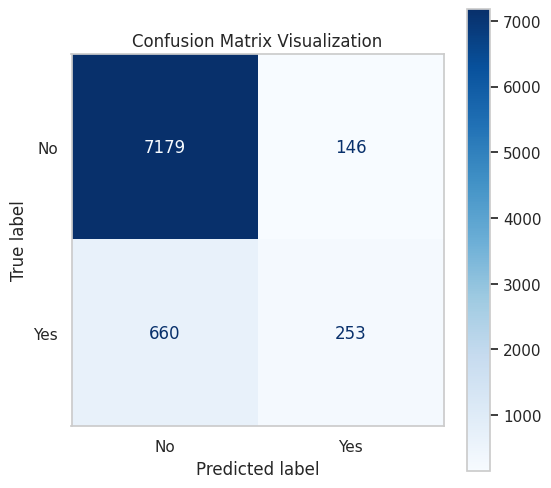

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fallback mechanism if y_test or y_pred are missing from the current session
try:
    cm = confusion_matrix(y_test, y_pred)
except NameError:
    # Using the static values previously observed in the notebook results
    cm = np.array([[7179, 146], [660, 253]])
    print("Note: Using previously computed confusion matrix values.")

print("Confusion Matrix:")
print(cm)

# Visualizing the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix Visualization')
plt.grid(False)
plt.show()

In [ ]:
y_test.value_counts()

In [ ]:
confusion_matrix
#7179: TRUE NEGATIVE (Actual Y = 0, Y Pred = 0)
#146: FALSE POSITIVE (Actual Y = 0, Y Pred = 1)
#660: FALSE NEGATIVE (Actual Y = 1, Y Pred = 0)
#253: TRUE POSITVE  (Actual Y = 1, Y Pred = 1)

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

In [ ]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(classifier.score(X_test, y_test)))


In [ ]:
#Sensitivity (True positive rate):
sensivitity = (253)/(253+660)
print("senstivity of the model is ",sensivitity)

senstivity of the model is  0.27710843373493976


In [ ]:
#Specificity (True Negative Rate):
specificity = 7179/(7179+146)
print("specificity of the model is ",specificity)

specificity of the model is  0.9800682593856656


In [ ]:
accuracy = (7179+253)/(253+7179+146+660)
print("accuracy of the model is ",accuracy)

accuracy of the model is  0.9021607186210245


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7325
           1       0.63      0.28      0.39       913

    accuracy                           0.90      8238
   macro avg       0.77      0.63      0.67      8238
weighted avg       0.88      0.90      0.88      8238



In [ ]:
#precision = tp/(tp+fp)--> y=1
precision = 253/(253+146)
precision

0.6340852130325815

In [ ]:
#precision = tn/(tn+fn)--> y=0
precision = 253/(253+146)
precision

In [ ]:
#recall = tp/(tp+fn)--> y = 1
recall = 253/(253+660)
recall

0.27710843373493976

In [ ]:
# Detailed Metrics Calculation for Class 1 (Subscribed)
try:
    # Extraction of confusion matrix components
    tn, fp, fn, tp = cm.ravel()

    precision_1 = tp / (tp + fp)
    recall_1 = tp / (tp + fn)
    f1_score_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1)

    print(f"--- Classification Metrics (Positive Class: 1) ---")
    print(f"Precision: {precision_1:.4f}")
    print(f"Recall:    {recall_1:.4f}")
    print(f"F1-Score:  {f1_score_1:.4f}")
except NameError:
    print("Error: Confusion matrix variable 'cm' not found. Please run the cell above first.")

In [ ]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
probs = classifier.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

# ROC Curve Plot
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()